# télécharger des librairies necessaires #

In [1]:
pip install vaderSentiment

Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install flair

Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install --upgrade numpy pandas

Note: you may need to restart the kernel to use updated packages.


In [4]:
pip install textblob

Note: you may need to restart the kernel to use updated packages.


In [5]:
# Import the necessary libraries/packages
# Data processing
import pandas as pd
import numpy as np

# Import TextBlob
from textblob import TextBlob
from textblob import Blobber
from textblob.sentiments import NaiveBayesAnalyzer

# Import VADER sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Import flair pre-trained sentiment model
from flair.models import TextClassifier
classifier = TextClassifier.load('en-sentiment')

# Import flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set a wider colwith
pd.set_option('display.max_colwidth', 1000)

c:\Users\joachim.querule\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Read in data
amz_review = pd.read_csv(r'data\amazon_cells_labelled.txt', sep='\t', names=['review', 'label'])

# Take a look at the data
amz_review.head()

,review,label
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0
1,"Good case, Excellent value.",1
2,Great for the jawbone.,1
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0
4,The mic is great.,1


In [7]:
# Check the label distribution
amz_review['label'].value_counts()

label
0    500
1    500
Name: count, dtype: int64

# What is TextBlob? #

TextBlob est une bibliothèque Python pour le traitement du langage naturel (NLP). L’analyse de sentiment est l’une des nombreuses tâches NLP prises en charge par TextBlob.

TextBlob propose deux méthodes principales d’analyse du sentiment : l’analyseur de motifs et l’analyseur naïf-bayes. Chaque méthode utilise une approche différente pour analyser le sentiment du texte.

Analyseur de motifs : C’est l’analyseur par défaut dans TextBlob. Il est basé sur la bibliothèque de motifs et utilise un lexique (une liste de mots connus avec leurs scores de sentiment associés). La note de sentiment est un tuple représentant la polarité et la subjectivité.
La propriété de sentiment dans TextBlob par défaut en utilisant l’Anlyzer de Pattern. Il retourne un score de polarité et un score de subjectivité pour le texte d’entrée.

Le score de polarité varie de -1 à 1, où -1 signifie extrêmement négatif, et 1 signifie très positif. Un score proche de 0 signifie un sentiment neutre.
Le score de subjectivité varie de 0 à 1, où 0 signifie extrêmement objectif et 1 signifie hautement subjectif.
Analyseur naïf Bayes : Cela utilise un classificateur Naive Bayes entraîné sur un ensemble de données de critiques de films. Il est plus contextuel comparé à l’analyseur de motifs basé sur le lexique. Cet analyseur classe le texte en catégories « pos » ou « négative », fournissant une classification probabiliste par sentiment.

In [8]:
!python -m textblob.download_corpora
# to executes the TextBlob module's script to download necessary data,
# including datasets and corpora used for tasks like part-of-speech tagging, noun phrase extraction, and sentiment analysis.

Finished.


[nltk_data] Downloading package brown to
[nltk_data]     C:\Users\joachim.querule\AppData\Roaming\nltk_data...
[nltk_data]   Package brown is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\joachim.querule\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\joachim.querule\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\joachim.querule\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package conll2000 to
[nltk_data]     C:\Users\joachim.querule\AppData\Roaming\nltk_data...
[nltk_data]   Package conll2000 is already up-to-date!
[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\joachim.querule\AppData\Roa

In [9]:
from textblob.sentiments import NaiveBayesAnalyzer

# Example text
text = "I love this product, it's absolutely wonderful!"

# Using Pattern Analyzer
blob_pattern = TextBlob(text)
print("Pattern Analyzer Sentiment:")
print("Polarity:", blob_pattern.sentiment.polarity)
print("Subjectivity:", blob_pattern.sentiment.subjectivity)

# Using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text, analyzer=NaiveBayesAnalyzer())
print("\nNaive Bayes Analyzer Sentiment:")
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Pattern Analyzer Sentiment:
Polarity: 0.75
Subjectivity: 0.8

Naive Bayes Analyzer Sentiment:
Classification: pos
Positive Probability: 0.6560203571571461
Negative Probability: 0.34397964284285404


In [10]:
# List of words to check
words = ["happy", "sad", "neutral", "exciting", "frustrating","crazy","yummy", ":D", "}:("]

# Checking the sentiment of each word
for word in words:
    blob = TextBlob(word)
    print(f"Word: {word}, Sentiment: {blob.sentiment}")


Word: happy, Sentiment: Sentiment(polarity=0.8, subjectivity=1.0)
Word: sad, Sentiment: Sentiment(polarity=-0.5, subjectivity=1.0)
Word: neutral, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: exciting, Sentiment: Sentiment(polarity=0.3, subjectivity=0.8)
Word: frustrating, Sentiment: Sentiment(polarity=-0.4, subjectivity=0.9)
Word: crazy, Sentiment: Sentiment(polarity=-0.6, subjectivity=0.9)
Word: yummy, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: :D, Sentiment: Sentiment(polarity=1.0, subjectivity=1.0)
Word: }:(, Sentiment: Sentiment(polarity=-0.75, subjectivity=1.0)


In [11]:
# Example text
text = 'It is an interesting movie.'

# TextBlob sentiment
textBlob_sentiment = TextBlob(text).sentiment
textBlob_sentiment

Sentiment(polarity=0.5, subjectivity=0.5)

In [12]:
# Example text
text = 'It is a very interesting movie.'

# TextBlob sentiment
textBlob_sentiment = TextBlob(text).sentiment
textBlob_sentiment

Sentiment(polarity=0.65, subjectivity=0.65)

In [13]:
# Extract sentiment score
textBlob_sentiment.polarity

0.65

In [14]:
text2 = "This movie is not interesting."

# TextBlob sentiment
textBlob_sentiment2 = TextBlob(text2).sentiment
textBlob_sentiment2

Sentiment(polarity=-0.25, subjectivity=0.5)

In [15]:
# Extract sentiment score
textBlob_sentiment2.polarity

-0.25

In [16]:
# TextBlob sentiment using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text2, analyzer=NaiveBayesAnalyzer())
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Classification: neg
Positive Probability: 0.4540202655486483
Negative Probability: 0.5459797344513515


In [17]:
text3 = "I cannot say that this movie is interesting."

# TextBlob sentiment
textBlob_sentiment3 = TextBlob(text3).sentiment
textBlob_sentiment3

Sentiment(polarity=0.5, subjectivity=0.5)

In [18]:
# Extract sentiment score
textBlob_sentiment2.polarity

-0.25

In [19]:
# TextBlob sentiment using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text3, analyzer=NaiveBayesAnalyzer())
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Classification: neg
Positive Probability: 0.4468402964070675
Negative Probability: 0.5531597035929323


VADER (Valence Aware Dictionary and sEntiment Reasoner) est une bibliothèque Python axée sur les sentiments sur les réseaux sociaux. Il dispose d’un algorithme intégré pour modifier l’intensité des sentiments en fonction de la ponctuation, de l’argot, des emojis et des acronymes.

La sortie du VADER comprend quatre scores : score composé, score négatif, score neutre et score positif.

Les pos, neu et neg représentent le pourcentage de jetons appartenant à chaque catégorie, donc ils totalisent 100 %.
Le score composé est un score unique pour mesurer le sentiment du texte. À l’instar de TextBlob, il varie de -1 (extrêmement négatif) à 1 (extrêmement positif). Les scores proches de 0 représentent le score de sentiment neuronal.
Le score composé n’est pas une simple agrégation des scores pos, neu et neg. À la place, il intègre des améliorations basées sur des règles telles que des amplificateurs de ponctuation.

In [20]:
# Take a peek on VADER's lexicon
import nltk

# Download VADER lexicon
nltk.download('vader_lexicon')

# Import the SentimentIntensityAnalyzer
from nltk.sentiment.vader import SentimentIntensityAnalyzer

# Create an instance of SentimentIntensityAnalyzer
sid = SentimentIntensityAnalyzer()

# Accessing the lexicon (a dictionary of words and their sentiment scores)
vader_lexicon = sid.lexicon

# Displaying a portion of the lexicon
for word in list(vader_lexicon.keys())[-30:]:  # Display last 30 words for brevity
    print(f"{word}: {vader_lexicon[word]}")


wrong: -2.1
wronged: -1.9
yay: 2.4
yeah: 1.2
yearning: 0.5
yeees: 1.7
yep: 1.2
yes: 1.7
youthful: 1.3
yucky: -1.8
yummy: 2.4
zealot: -1.9
zealots: -0.8
zealous: 0.5
{:: 1.8
|-0: -1.2
|-:: -0.8
|-:>: -1.6
|-o: -1.2
|:: -0.5
|;-): 2.2
|=: -0.4
|^:: -1.1
|o:: -0.9
||-:: -2.3
}:: -2.1
}:(: -2.0
}:): 0.4
}:-(: -2.1
}:-): 0.3


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\joachim.querule\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


With an absent of any semantic tokens or punctuation, VADER assigns a completely neutral score or zero

In [21]:
# Let's test using blank text
text = ""

# VADER Sentiment
vader = SentimentIntensityAnalyzer()
vader_sentiment = vader.polarity_scores(text)
vader_sentiment

{'neg': 0.0, 'neu': 0.0, 'pos': 0.0, 'compound': 0.0}

In [22]:
# Example text
text = 'It is an interesting movie.'

# VADER Sentiment
vader = SentimentIntensityAnalyzer()
vader_sentiment = vader.polarity_scores(text)
vader_sentiment

{'neg': 0.0, 'neu': 0.597, 'pos': 0.403, 'compound': 0.4019}

In [23]:
# Example text
text = 'It is a very interesting movie.'

# VADER Sentiment
vader = SentimentIntensityAnalyzer()
vader_sentiment = vader.polarity_scores(text)
vader_sentiment

{'neg': 0.0, 'neu': 0.572, 'pos': 0.428, 'compound': 0.4576}

VADER a donné un score composé de texte d’exemple de 0,46. Il n’y a pas de mot négatif dans la phrase, donc la valeur du score négatif est 0. Il y a 63 % de mots neutres et 37,4 % de mots positifs dans la phrase.

La sortie du VADER est enregistrée sous forme de dictionnaire. Nous pouvons extraire le score de sentiment composé par la clé « composé ».

In [24]:
# Extract sentiment score
vader_sentiment['compound']

0.4576

Testons avec d’autres exemples

In [25]:
text2 = "This movie is not interesting."
vader_sentiment2 = vader.polarity_scores(text2)
vader_sentiment2

{'neg': 0.361, 'neu': 0.639, 'pos': 0.0, 'compound': -0.3089}

In [26]:
# Extract sentiment score
vader_sentiment2['compound']

-0.3089

In [27]:
text3 = "I cannot say that this movie is interesting."
vader_sentiment3 = vader.polarity_scores(text3)
vader_sentiment3

{'neg': 0.0, 'neu': 0.69, 'pos': 0.31, 'compound': 0.4019}

Qu’est-ce que Flair
Flair est un framework NLP de pointe construit sur PyTorch. Il intègre des recherches récentes et offre un moyen simple de combiner différents embeddings dans diverses tâches de NLP. Le modèle de sentiment pré-entraîné offre un outil d’analyse de sentiment sans entraîner un modèle personnalisé.

Contrairement à TextBlob et VADER qui affichent un score de sentiment entre -1 et 1, le flair sentiment affiche le label prédit avec un score de confiance. Le score de confiance varie de 0 à 1, 1 étant très confiant et 0 très peu confiant.

Avant de prédire le sentiment d’un texte, le texte d’entrée doit être tokenisé par . Ensuite, on peut voir que le texte d’exemple a été divisé en neuf jetons.Sentence()

In [28]:
# Example text
text = 'It is an interesting movie.'

# Flair tokenization
sentence = Sentence(text)
sentence

Sentence[6]: "It is an interesting movie."

Next, we use `.predict` to predict the sentiment.

In [29]:
# Flair sentiment prediction
classifier.predict(sentence)
sentence

Sentence[6]: "It is an interesting movie." → POSITIVE (0.9853)

In [30]:
# Example text
text = 'It is a very interesting movie.'

# Flair tokenization
sentence = Sentence(text)
sentence

Sentence[7]: "It is a very interesting movie."

In [31]:
# Flair sentiment prediction
classifier.predict(sentence)
sentence

Sentence[7]: "It is a very interesting movie." → POSITIVE (0.9958)

Le texte d’exemple présente le sentiment prédit de POSITIF et un score de confiance de 0,9958. Comme 0,9958 est proche de 1, Flair est très confiant dans les prédictions.

L’étiquette prédite est enregistrée comme valeur et la confiance dans la prédiction est enregistrée comme score. Nous pouvons utiliser et extraire séparément les valeurs.sentence.labels[0].valuesentence.labels[0].score

In [32]:
# Extract sentiment prediction score
print(f'Flair classified the review as {sentence.labels[0].value} with the score of {sentence.labels[0].score:.2f}')

Flair classified the review as POSITIVE with the score of 1.00


Testons avec d’autres exemples

In [33]:
# Example text
text2 = 'This movie is not interesting.'

# Flair tokenization
sentence2 = Sentence(text2)
sentence2

Sentence[6]: "This movie is not interesting."

In [34]:
# Flair sentiment prediction
classifier.predict(sentence2)
sentence2

Sentence[6]: "This movie is not interesting." → NEGATIVE (0.9999)

In [35]:
# Extract sentiment prediction score
print(f'Flair classified the review as {sentence2.labels[0].value} with the score of {sentence2.labels[0].score:.2f}')

Flair classified the review as NEGATIVE with the score of 1.00


In [36]:
# Example text
text3 = 'I cannot say that this movie is interesting.'

# Flair tokenization
sentence3 = Sentence(text3)
sentence3

Sentence[9]: "I cannot say that this movie is interesting."

In [37]:
# Flair sentiment prediction
classifier.predict(sentence3)
sentence3

Sentence[9]: "I cannot say that this movie is interesting." → POSITIVE (0.7052)

In [38]:
# Extract sentiment prediction score
print(f'Flair classified the review as {sentence3.labels[0].value} with the score of {sentence3.labels[0].score:.2f}')

Flair classified the review as POSITIVE with the score of 0.71


Comment utiliser TextBlob pour l’analyse de sentiment
Nous allons appliquer TextBlob à l’ensemble de données de revue Amazon et voir comment il se comporte.

Nous obtenons d’abord la polarité du sentiment pour chaque critique et enregistrons les valeurs dans une colonne appelée « scores_TextBlob ». Ensuite, vérifie si le score de polarité est positif. Si le score est supérieur ou égal à zéro, le sentiment prédit pour l’évaluation est positif (indiqué 1). Sinon, le sentiment prédit pour l’avis est négatif (indiqué comme 0).

In [39]:
# Get sentiment score for each review
amz_review['scores_TextBlob'] = amz_review['review'].apply(lambda s: TextBlob(s).sentiment.polarity)

# Predict sentiment label for each review
amz_review['pred_TextBlob'] = amz_review['scores_TextBlob'].apply(lambda x: 1 if x >=0 else 0)
amz_review.head()

,review,label,scores_TextBlob,pred_TextBlob
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,0.000000,1
1,"Good case, Excellent value.",1,0.850000,1
2,Great for the jawbone.,1,0.800000,1
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,0.390625,1
4,The mic is great.,1,0.800000,1


Après avoir obtenu les prédictions de TextBlob, vérifions la précision des prédictions.

In [40]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
actual_labels = amz_review['label']
predicted_labels = amz_review['pred_TextBlob']

accuracy_TextBlob = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_TextBlob = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob)
print(f'Precision:', precision_TextBlob)
print(f'Recall:', recall_TextBlob)
print(f'F1:', f1_TextBlob)

Accuracy: 0.687
Precision: 0.7715512985089366
Recall: 0.6869999999999999
F1: 0.6605791409073707


En comparant l’étiquette réelle avec la prédiction de TextBlob, nous obtenons un score de précision de 0,688, ce qui signifie que TextBlob a prédit le sentiment d’avis 68,8 % du temps.

# Utilisez le classificateur Naive Bayes #

In [41]:
# Function to apply Naive Bayes Sentiment Analysis
def naive_bayes_sentiment(text):
    blob = TextBlob(text, analyzer=NaiveBayesAnalyzer())
    return blob.sentiment.classification

# # Applying the Naive Bayes classifier to get sentiment
# amz_review['naive_bayes_analysis'] = amz_review['review'].apply(naive_bayes_sentiment)

# # Predict sentiment label (1 for positive, 0 for negative)
# amz_review['pred_TextBlob_NaiveBayes'] = amz_review['naive_bayes_analysis'].apply(lambda x: 1 if x.classification == 'pos' else 0)
# amz_review.head()

# Slice the DataFrame to process only the top 100 rows (only for example in this coding practice)
amz_review_top100 = amz_review.head(100).copy()

# Applying the Naive Bayes classifier to get sentiment for the top 30 rows
amz_review_top100['naive_bayes_analysis'] = amz_review_top100['review'].apply(naive_bayes_sentiment)

# Predict sentiment label (1 for positive, 0 for negative)
amz_review_top100['pred_TextBlob_NaiveBayes'] = amz_review_top100['naive_bayes_analysis'].apply(lambda x: 1 if x == 'pos' else 0)

# Display the first few rows of the processed DataFrame
amz_review_top100.head()

,review,label,scores_TextBlob,pred_TextBlob,naive_bayes_analysis,pred_TextBlob_NaiveBayes
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,0.000000,1,neg,0
1,"Good case, Excellent value.",1,0.850000,1,pos,1
2,Great for the jawbone.,1,0.800000,1,pos,1
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,0.390625,1,pos,1
4,The mic is great.,1,0.800000,1,neg,0


Calculating the Accurancy, Precision, Recall, and F1 score from the result of TextBlob - Naive Bayes

In [42]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
# actual_labels = amz_review['label']
# predicted_labels = amz_review['pred_TextBlob_NaiveBayes']

# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score for the top 100 data
actual_labels = amz_review_top100['label']
predicted_labels = amz_review_top100['pred_TextBlob_NaiveBayes']

accuracy_TextBlob_NB = accuracy_score(actual_labels,predicted_labels)
precision_TextBlob_NB = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_TextBlob_NB = recall_score(actual_labels, predicted_labels, average='macro')
f1_TextBlob_NB = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_TextBlob_NB)
print(f'Precision:', precision_TextBlob_NB)
print(f'Recall:', recall_TextBlob_NB)
print(f'F1:', f1_TextBlob_NB)

Accuracy: 0.63
Precision: 0.6412655971479502
Recall: 0.6268507402961184
F1: 0.6189887756152817


# Comment utiliser VADER pour l’analyse de sentiment #

Nous allons appliquer VADER à l’ensemble de données d’évaluation Amazon et voir comment il se comporte.

Nous obtenons d’abord le score composé de sentiment pour chaque avis et enregistrons les valeurs dans une colonne appelée « scores_VADER ». Ensuite, vérifiez si le score composé est positif. Si le score est supérieur ou égal à zéro, le sentiment prédit pour l’évaluation est positif (indiqué 1). Sinon, le sentiment prédit pour l’avis est négatif (indiqué comme 0).

In [43]:
# Get sentiment score for each review
vader_sentiment = SentimentIntensityAnalyzer()
amz_review['scores_VADER'] = amz_review['review'].apply(lambda s: vader_sentiment.polarity_scores(s)['compound'])

# Predict sentiment label for each review
amz_review['pred_VADER'] = amz_review['scores_VADER'].apply(lambda x: 1 if x >=0 else 0)
amz_review.head()

,review,label,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,0.000000,1,-0.3535,0
1,"Good case, Excellent value.",1,0.850000,1,0.8402,1
2,Great for the jawbone.,1,0.800000,1,0.6249,1
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,0.390625,1,-0.6145,0
4,The mic is great.,1,0.800000,1,0.6249,1


After getting predictions from VADER, let's check the prediction accuracy.

In [44]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
actual_labels = amz_review['label']
predicted_labels = amz_review['pred_VADER']

accuracy_VADER = accuracy_score(actual_labels,predicted_labels)
precision_VADER = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_VADER = recall_score(actual_labels, predicted_labels, average='macro')
f1_VADER = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_VADER)
print(f'Precision:', precision_VADER)
print(f'Recall:', recall_VADER)
print(f'F1:', f1_VADER)

Accuracy: 0.758
Precision: 0.815860609978257
Recall: 0.758
F1: 0.746385468935364


Comparing the actual label with the VADER prediction, we get an accuracy score of 0.768, which means that VADER predicted the review sentiment 76.8% of the time.

TextBlob has a prediction accuracy of 68.8% for the same dataset, so VADER has an 8% improvement over the TextBlob prediction.

# How To Use Flair For Sentiment Analysis #

We will apply the flair pre-trained sentiment model to predict the sentiment of the Amazon reviews.

Firstly, let's define a function that takes a review as input and the predicted label and confidence as outputs.

In [45]:
# Define a function to get Flair sentiment prediction score
def score_flair(text):
  sentence = Sentence(text)
  classifier.predict(sentence)
  score = sentence.labels[0].score
  value = sentence.labels[0].value
  return score, value

Then apply the function to each review in the dataset.

In [46]:
# Get sentiment score for each review
amz_review['scores_flair'] = amz_review['review'].apply(lambda s: score_flair(s)[0])

# Predict sentiment label for each review
amz_review['pred_flair'] = amz_review['review'].apply(lambda s: score_flair(s)[1])

In [47]:
amz_review.head()

,review,label,scores_TextBlob,pred_TextBlob,scores_VADER,pred_VADER,scores_flair,pred_flair
0,So there is no way for me to plug it in here in the US unless I go by a converter.,0,0.000000,1,-0.3535,0,0.998717,NEGATIVE
1,"Good case, Excellent value.",1,0.850000,1,0.8402,1,0.998424,POSITIVE
2,Great for the jawbone.,1,0.800000,1,0.6249,1,0.995642,POSITIVE
3,Tied to charger for conversations lasting more than 45 minutes.MAJOR PROBLEMS!!,0,0.390625,1,-0.6145,0,0.999925,NEGATIVE
4,The mic is great.,1,0.800000,1,0.6249,1,0.979156,POSITIVE


In [48]:
# Check the distribution of the score
amz_review['scores_flair'].describe()

count    1000.000000
mean        0.988019
std         0.046841
min         0.533637
25%         0.996153
50%         0.999167
75%         0.999887
max         0.999999
Name: scores_flair, dtype: float64

We can see that the summary statistics show that most flair scores are close to 1, which means that the flair sentiment model is overall very confident about the predictions.

In [49]:
# Check the counts of labels
amz_review['pred_flair'].value_counts()

pred_flair
POSITIVE    504
NEGATIVE    496
Name: count, dtype: int64

The distribution of the labels is very balanced.

Before checking the prediction accuracy etc, we need to map the 'NEGATIVE' value to 0 and the 'POSITIVE' value to 1 because the Amazon review dataset has true labels of 0 and 1.



In [50]:
# Change the label of flair prediction to 0 if negative and 1 if positive
mapping = {'NEGATIVE': 0, 'POSITIVE': 1}
amz_review['pred_flair'] = amz_review['pred_flair'].map(mapping)

In [51]:
# Check counts
amz_review['pred_flair'].value_counts()

pred_flair
1    504
0    496
Name: count, dtype: int64

In [52]:
# Compare Actual and Predicted and get the Accuracy, Precision, Recall, and F1 score
actual_labels = amz_review['label']
predicted_labels = amz_review['pred_flair']

accuracy_flair = accuracy_score(actual_labels,predicted_labels)
precision_flair = precision_score(actual_labels, predicted_labels, average='macro')  # Use 'micro' or 'weighted' if more appropriate
recall_flair = recall_score(actual_labels, predicted_labels, average='macro')
f1_flair = f1_score(actual_labels, predicted_labels, average='macro')

print(f'Accuracy:', accuracy_flair)
print(f'Precision:', precision_flair)
print(f'Recall:', recall_flair)
print(f'F1:', f1_flair)

Accuracy: 0.948
Precision: 0.9480286738351255
Recall: 0.948
F1: 0.9479991679866878


After comparing the flair prediction with the actual sentiment label, we can see that flair predicts the sentiment correctly 94.8% of the time! The prediction accuracy is an 18% increase from VADER and a 26% increase from TextBlob!

# Visualisation #

In [53]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


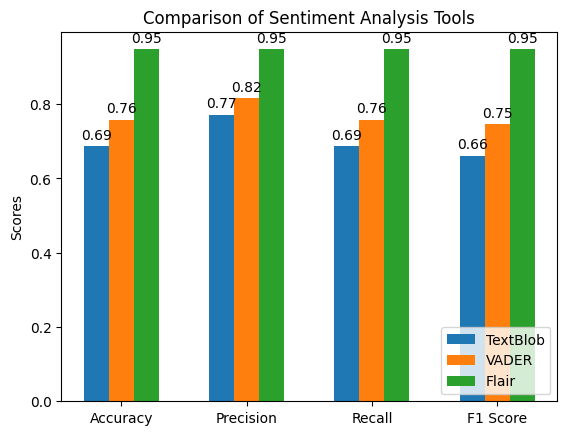

In [54]:
import matplotlib.pyplot as plt

# Conver the results in lists
textblob_values = [accuracy_TextBlob, precision_TextBlob, recall_TextBlob, f1_TextBlob]
# textblobNB_values = [accuracy_TextBlob_NB, precision_TextBlob_NB, recall_TextBlob_NB, f1_TextBlob_NB]
vader_values = [accuracy_VADER, precision_VADER, recall_VADER, f1_VADER]
flair_values = [accuracy_flair, precision_flair, recall_flair, f1_flair]

labels = ['Accuracy', 'Precision', 'Recall', 'F1 Score']

# Setting the positions and width for the bars
x = range(len(labels))  # the label locations
width = 0.2  # the width of the bars

# Plotting
fig, ax = plt.subplots()
rects1 = ax.bar(x, textblob_values, width, label='TextBlob')
rects2 = ax.bar([p + width for p in x], vader_values, width, label='VADER')
rects3 = ax.bar([p + width * 2 for p in x], flair_values, width, label='Flair')

# Add some text for labels, title, and custom x-axis tick labels
ax.set_ylabel('Scores')
ax.set_title('Comparison of Sentiment Analysis Tools')
ax.set_xticks([p + width for p in x])
ax.set_xticklabels(labels)
ax.legend(loc='lower right')

# Function to add labels on the bars
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

# Attach labels
autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

# Show the plot
plt.show()


# Summary: TextBlob vs. VADER vs. Flair #

In this tutorial, we compared TextBlob vs. VADER vs. Flair for sentiment analysis.

Methodology
VADER and TextBlob are lexicon and rule-based.
Flair is model-based.
Meaning of score
VADER and TextBlob have sentiment scores ranging from -1 to 1, where -1 means very negative, 1 means very positive, and 0 means neutral.
Flair has a score ranging from 0 to 1, where 0 means very unconfident about the prediction and 1 means very confident about the prediction.
Speed Performance
Flair is slower than TextBlob and VADER because the computation algorithm is more complicated.
Accuracy Performance
Based on the results of this project, flair has the best prediction accuracy, VADER is the second-best, and TextBlob is the third.

# exercice #

In [55]:
# Import the necessary libraries/packages
# Data processing
import pandas as pd
import numpy as np

# Import TextBlob
from textblob import TextBlob
from textblob import Blobber
from textblob.sentiments import NaiveBayesAnalyzer

# Import VADER sentiment
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

# Import flair pre-trained sentiment model
from flair.models import TextClassifier
classifier = TextClassifier.load('en-sentiment')

# Import flair Sentence to process input text
from flair.data import Sentence

# Import accuracy_score to check performance
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Set a wider colwith
pd.set_option('display.max_colwidth', 1000)

In [56]:
# Read in data
knowledge_review = pd.read_csv(r'data\knowledge.txt', sep='.', names=['review', 'label'])

# Take a look at the data
knowledge_review.head()

,review,label
0,Le machine learning supervisé consiste à apprendre une relation entre des variables d'entrée et une cible,NaN
1,La classification prédit une classe,NaN
2,La régression prédit une valeur continue,NaN
3,Le surapprentissage apparaît quand le modèle mémorise trop les données d'entraînement et généralise mal,NaN
4,La validation croisée permet d'évaluer plus robustement les performances d'un modèle,NaN


In [57]:
from textblob.sentiments import NaiveBayesAnalyzer

# Example text
text = knowledge_review["review"].iloc[0] 

# Using Pattern Analyzer
blob_pattern = TextBlob(text=r'data\knowledge.txt')
print("Pattern Analyzer Sentiment:")
print("Polarity:", blob_pattern.sentiment.polarity)
print("Subjectivity:", blob_pattern.sentiment.subjectivity)

# Using Naive Bayes Analyzer
blob_naivebayes = TextBlob(text, analyzer=NaiveBayesAnalyzer())
print("\nNaive Bayes Analyzer Sentiment:")
print("Classification:", blob_naivebayes.sentiment.classification)
print("Positive Probability:", blob_naivebayes.sentiment.p_pos)
print("Negative Probability:", blob_naivebayes.sentiment.p_neg)

Pattern Analyzer Sentiment:
Polarity: 0.0
Subjectivity: 0.0

Naive Bayes Analyzer Sentiment:
Classification: pos
Positive Probability: 0.8819241982507292
Negative Probability: 0.11807580174927133


In [60]:
# List of words to check
words = ["happy", "sad", "neutral", "exciting", "frustrating","crazy","yummy", ":D", "}:("]

# Checking the sentiment of each word
for word in words:
    blob = TextBlob(text=r'data\knowledge.txt')
    print(f"Word: {word}, Sentiment: {blob.sentiment}")


Word: happy, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: sad, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: neutral, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: exciting, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: frustrating, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: crazy, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: yummy, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: :D, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
Word: }:(, Sentiment: Sentiment(polarity=0.0, subjectivity=0.0)
